**Chilli Plant Disease Detection**

In [ ]:
import os
from sklearn.model_selection import train_test_split
import shutil
import random
import time
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torchvision
from torchvision import datasets , models , transforms
from torch.utils.data import DataLoader

from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

from torch import optim
import torch.nn.functional as F

import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

In [ ]:
base_folder = r'/content/drive/My Drive/Dataset'  # in New Folder create Dataset as subfolder and that subfolder contains different classes i.e., Flowering, Growing, Mature, Seeding and Wilting
dataset_folder = os.path.join(base_folder, 'Dataset')
new_folder = os.path.join(base_folder, 'data')

In [ ]:
class_folders = [f for f in os.listdir(dataset_folder) if os.path.isdir(os.path.join(dataset_folder, f))]
class_folders

['White spot',
 'Nutrition Deficiency',
 'Healthy Leaf',
 'Cercospora Leaf Spot',
 'Curl Virus',
 'Bacterial Spot']

In [ ]:
os.makedirs(new_folder, exist_ok=True)

In [ ]:
import random

In [ ]:
for class_folder in class_folders:
    class_path = os.path.join(dataset_folder, class_folder)
    images = os.listdir(class_path)

    # Shuffle the images randomly
    random.shuffle(images)

    # Split the images into train, test, and validation sets
    train_images, temp_images = train_test_split(images, train_size=0.8, random_state=42)
    test_images, val_images = train_test_split(temp_images, train_size=0.5, random_state=42)

    # Create folders for train, test, and validation sets within the 'data' folder
    train_folder = os.path.join(new_folder, 'train', class_folder)
    test_folder = os.path.join(new_folder, 'test', class_folder)
    val_folder = os.path.join(new_folder, 'val', class_folder)

    os.makedirs(train_folder, exist_ok=True)
    os.makedirs(test_folder, exist_ok=True)
    os.makedirs(val_folder, exist_ok=True)

    # Move images to the respective folders
    for image in train_images:
        shutil.move(os.path.join(class_path, image), os.path.join(train_folder, image))

    for image in test_images:
        shutil.move(os.path.join(class_path, image), os.path.join(test_folder, image))

    for image in val_images:
        shutil.move(os.path.join(class_path, image), os.path.join(val_folder, image))


In [ ]:
train_folder = os.path.join(new_folder, 'train')
num_total_train_images = sum(len(files) for _, _, files in os.walk(train_folder))

test_folder = os.path.join(new_folder, 'test')
num_total_test_images = sum(len(files) for _, _, files in os.walk(test_folder))

val_folder = os.path.join(new_folder, 'val')
num_total_val_images = sum(len(files) for _, _, files in os.walk(val_folder))

print(f"Total Train Images: {num_total_train_images}")
print(f"Total Test Images: {num_total_test_images}")
print(f"Total Validation Images: {num_total_val_images}")


Total Train Images: 1483
Total Test Images: 185
Total Validation Images: 188


**DATA LOADERS**

In [ ]:
mean_values = [0.485, 0.456, 0.406]
std_values = [0.229, 0.224, 0.225]

In [ ]:
normalize = transforms.Normalize(mean=mean_values, std=std_values)

In [ ]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=256, scale=(0.8, 1.0)),
    transforms.RandomRotation(30),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    normalize,
])

val_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=256, scale=(0.8, 1.0)),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize,
])

test_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=256, scale=(0.8, 1.0)),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize,
])

In [ ]:
# Create custom dataset
train_dataset = datasets.ImageFolder(os.path.join(new_folder, 'train'), transform=train_transforms)
val_dataset = datasets.ImageFolder(os.path.join(new_folder, 'val'), transform=val_transforms)
test_dataset = datasets.ImageFolder(os.path.join(new_folder, 'test'), transform=test_transforms)

In [ ]:
data_loaders = {x: DataLoader(
                    datasets.ImageFolder(os.path.join(new_folder, x),
                                         transform=train_transforms if x == 'train' else
                                                   val_transforms if x == 'val' else test_transforms),
                    batch_size=32,
                    shuffle=True if x == 'train' else False)
                for x in ['train', 'val', 'test']}

In [ ]:
dataset_sizes = {x: len(datasets.ImageFolder(os.path.join(new_folder, x),
                 transform=train_transforms if x == 'train' else val_transforms if x == 'val' else test_transforms))
                 for x in ['train', 'val', 'test']}

class_names = datasets.ImageFolder(os.path.join(new_folder, 'train'), transform=train_transforms).classes

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [ ]:
class_names, device , dataset_sizes

(['Bacterial Spot',
  'Cercospora Leaf Spot',
  'Curl Virus',
  'Healthy Leaf',
  'Nutrition Deficiency',
  'White spot'],
 device(type='cuda', index=0),
 {'train': 1483, 'val': 188, 'test': 185})

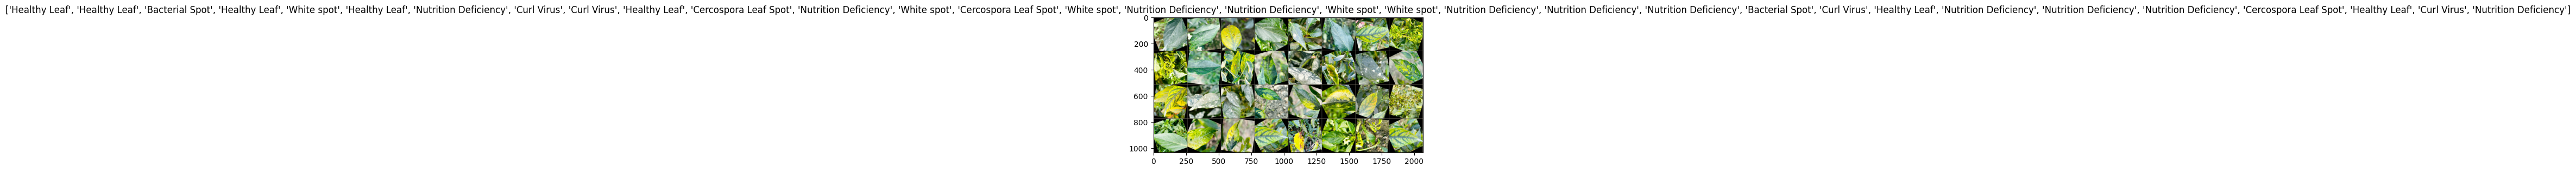

In [ ]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a batch of training data from your data loader
inputs, classes = next(iter(data_loaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

# Display the grid using the modified imshow function
imshow(out, title=[class_names[x] for x in classes])

# Show the plot
plt.show()


In [ ]:
help(models)

Help on package torchvision.models in torchvision:

NAME
    torchvision.models

PACKAGE CONTENTS
    _api
    _meta
    _utils
    alexnet
    convnext
    densenet
    detection (package)
    efficientnet
    feature_extraction
    googlenet
    inception
    maxvit
    mnasnet
    mobilenet
    mobilenetv2
    mobilenetv3
    optical_flow (package)
    quantization (package)
    regnet
    resnet
    segmentation (package)
    shufflenetv2
    squeezenet
    swin_transformer
    vgg
    video (package)
    vision_transformer

FILE
    /usr/local/lib/python3.12/dist-packages/torchvision/models/__init__.py




**VGG16**

In [ ]:
model_ft = models.vgg16(pretrained=True)
model_ft

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 76.8MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
def count_params(model):
  model_params = {"Modules": list(), "Parameters": list()}
  total = {"trainable": 0, "non_trainable": 0}
  for name, parameters in model.named_parameters():
    param = parameters.numel()
    if not parameters.requires_grad:
      total["non_trainable"] += param
      continue
    model_params["Modules"].append(name)
    model_params["Parameters"].append(param)
    total["trainable"] += param
  df = pd.DataFrame(model_params)
  df = df.style.set_caption(f"Total parameters: {total}")
  return df

In [ ]:
count_params(model_ft)

,Modules,Parameters
0,features.0.weight,1728
1,features.0.bias,64
2,features.2.weight,36864
3,features.2.bias,64
4,features.5.weight,73728
5,features.5.bias,128
6,features.7.weight,147456
7,features.7.bias,128
8,features.10.weight,294912
9,features.10.bias,256


In [ ]:
for parameters in model_ft.parameters():
  parameters.requires_grad = False

In [ ]:
count_params(model_ft)

,Modules,Parameters


In [ ]:
model_ft.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [ ]:
model_ft.classifier = nn.Sequential(
    nn.Linear(in_features=25088, out_features=100, bias=True),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.5, inplace=False),
    nn.Linear(in_features=100, out_features=6, bias=True)
)

In [ ]:
print(model_ft)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
count_params(model_ft)

,Modules,Parameters
0,classifier.0.weight,2508800
1,classifier.0.bias,100
2,classifier.3.weight,600
3,classifier.3.bias,6


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ft.parameters())

In [ ]:
def train_and_validate(model, loss_criterion, optimizer, train_data_loader, valid_data_loader, epochs=25, patience=20):
    '''
    Function to train and validate with early stopping
    Parameters
        :param model: Model to train and validate
        :param loss_criterion: Loss Criterion to minimize
        :param optimizer: Optimizer for computing gradients
        :param train_data_loader: DataLoader for training data
        :param valid_data_loader: DataLoader for validation data
        :param epochs: Number of epochs (default=25)
        :param patience: Number of epochs with no improvement after which training will be stopped (default=3)

    Returns
        model: Trained Model with best validation accuracy
        history: (list): List of lists containing training loss, validation loss, training accuracy, and validation accuracy for each epoch
    '''

    model.to(device)
    start = time.time()
    history = []
    best_acc = 0.0
    best_model_wts = model.state_dict()
    no_improvement = 0

    for epoch in range(epochs):
        epoch_start = time.time()
        print("Epoch: {}/{}".format(epoch+1, epochs))

        # Set to training mode
        model.train()

        # Loss and Accuracy within the epoch
        train_loss = 0.0
        train_acc = 0.0

        valid_loss = 0.0
        valid_acc = 0.0

        # Training loop with tqdm for progress tracking
        for i, (inputs, labels) in enumerate(tqdm(train_data_loader, desc="Training")):

            inputs = inputs.to(device)
            labels = labels.to(device)

            # Clean existing gradients
            optimizer.zero_grad()

            # Forward pass - compute outputs on input data using the model
            outputs = model(inputs)

            # Compute loss
            loss = loss_criterion(outputs, labels)

            # Backpropagate the gradients
            loss.backward()

            # Update the parameters
            optimizer.step()

            # Compute the total loss for the batch and add it to train_loss
            train_loss += loss.item() * inputs.size(0)

            # Compute the accuracy
            ret, predictions = torch.max(outputs.data, 1)
            correct_counts = predictions.eq(labels.data.view_as(predictions))

            # Convert correct_counts to float and then compute the mean
            acc = torch.mean(correct_counts.type(torch.FloatTensor))

            # Compute total accuracy in the whole batch and add to train_acc
            train_acc += acc.item() * inputs.size(0)

        # Validation loop with tqdm for progress tracking
        model.eval()  # Set model to evaluation mode
        for j, (inputs, labels) in enumerate(tqdm(valid_data_loader, desc="Validation")):
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass - compute outputs on input data using the model
            outputs = model(inputs)

            # Compute loss
            loss = loss_criterion(outputs, labels)

            # Compute the total loss for the batch and add it to valid_loss
            valid_loss += loss.item() * inputs.size(0)

            # Calculate validation accuracy
            ret, predictions = torch.max(outputs.data, 1)
            correct_counts = predictions.eq(labels.data.view_as(predictions))

            # Convert correct_counts to float and then compute the mean
            acc = torch.mean(correct_counts.type(torch.FloatTensor))

            # Compute total accuracy in the whole batch and add to valid_acc
            valid_acc += acc.item() * inputs.size(0)

        # Find average training loss and training accuracy
        avg_train_loss = train_loss / len(train_data_loader.dataset)
        avg_train_acc = train_acc / len(train_data_loader.dataset)

        # Find average validation loss and validation accuracy
        avg_valid_loss = valid_loss / len(valid_data_loader.dataset)
        avg_valid_acc = valid_acc / len(valid_data_loader.dataset)

        history.append([avg_train_loss, avg_valid_loss, avg_train_acc, avg_valid_acc])

        epoch_end = time.time()

        print("Epoch : {:03d}, Training: Loss: {:.4f}, Accuracy: {:.4f}%, \n\t\tValidation : Loss : {:.4f}, Accuracy: {:.4f}%, Time: {:.4f}s".format(epoch + 1, avg_train_loss, avg_train_acc * 100, avg_valid_loss, avg_valid_acc * 100, epoch_end - epoch_start))

        # Save if the model has the best accuracy till now
        if avg_valid_acc > best_acc:
            best_acc = avg_valid_acc
            best_model_wts = model.state_dict()
            no_improvement = 0  # Reset the counter for no improvement
        else:
            no_improvement += 1

        # Check for early stopping
        if no_improvement >= patience:
            print(f'Early stopping after {no_improvement} epochs with no improvement.')
            break

    model.load_state_dict(best_model_wts)

    print("Training complete in {:.0f}m {:.0f}s".format((time.time() - start) // 60, (time.time() - start) % 60))

    return model, history


In [ ]:
trained_model1 = train_and_validate(model_ft, criterion, optimizer, data_loaders['train'], data_loaders['val'], epochs=100)

Epoch: 1/100


Validation: 100%|██████████| 6/6 [02:08<00:00, 21.43s/it]


Epoch : 001, Training: Loss: 0.8230, Accuracy: 71.5442%, 
		Validation : Loss : 0.2830, Accuracy: 90.9574%, Time: 1125.1405s
Epoch: 2/100


Validation: 100%|██████████| 6/6 [00:03<00:00,  1.53it/s]


Epoch : 002, Training: Loss: 0.3310, Accuracy: 89.0762%, 
		Validation : Loss : 0.3005, Accuracy: 91.4894%, Time: 40.1508s
Epoch: 3/100


...

Epoch : 036, Training: Loss: 0.0616, Accuracy: 97.7748%, 
		Validation : Loss : 0.0784, Accuracy: 97.3404%, Time: 40.4469s
Epoch: 37/100


Validation: 100%|██████████| 6/6 [00:04<00:00,  1.43it/s]


Epoch : 037, Training: Loss: 0.0588, Accuracy: 97.8422%, 
		Validation : Loss : 0.0634, Accuracy: 98.4043%, Time: 40.4514s
Epoch: 38/100


Validation: 100%|██████████| 6/6 [00:04<00:00,  1.38it/s]

Epoch : 038, Training: Loss: 0.0538, Accuracy: 97.8422%, 
		Validation : Loss : 0.0464, Accuracy: 97.8723%, Time: 40.5114s
Early stopping after 20 epochs with no improvement.
Training complete in 43m 47s


In [ ]:
print(trained_model1)

(VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=

In [ ]:
trained_model, history_values = trained_model1

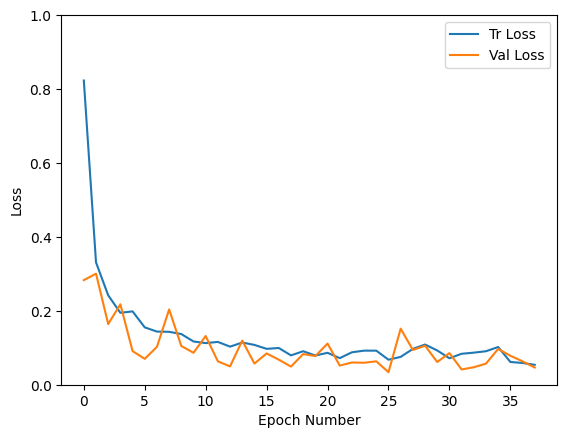

In [ ]:
history = np.array(history_values)
plt.plot(history[:,0:2])
plt.legend(['Tr Loss', 'Val Loss'])
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.ylim(0,1)
#plt.savefig(dataset+'_loss_curve.png')
plt.show()

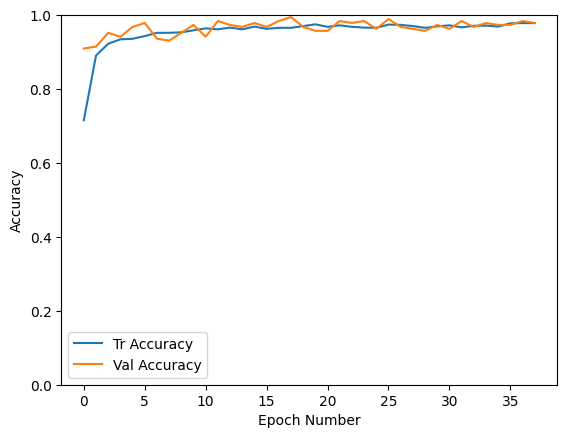

In [ ]:
plt.plot(history[:,2:4])
plt.legend(['Tr Accuracy', 'Val Accuracy'])
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')
plt.ylim(0,1)
#plt.savefig(dataset+'_accuracy_curve.png')
plt.show()

In [ ]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(data_loaders['test']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

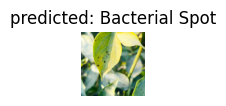

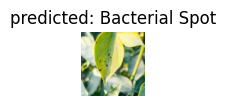

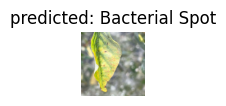

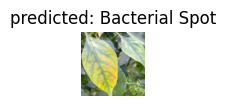

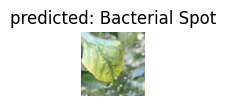

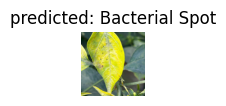

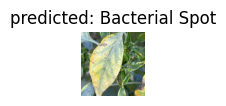

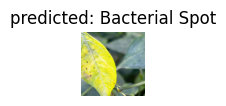

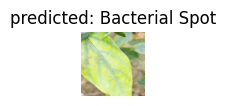

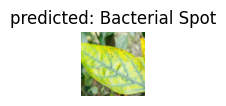

In [ ]:
visualize_model(trained_model,num_images=10)

In [ ]:
def test_model(model):
    since = time.time()
    phase = 'test'
    running_corrects = 0
    model.eval()   # Set model to evaluate mode

    preds_all = []
    labels_all = []

    with tqdm(data_loaders[phase], desc=f"{phase} Epoch", unit="batch") as tqdm_epoch:
        for inputs, labels in tqdm_epoch:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            preds_all.extend(preds.cpu().numpy().tolist())
            labels_all.extend(labels.data.cpu().numpy().tolist())

            running_corrects += torch.sum(preds == labels.data)
            tqdm_epoch.set_postfix(accuracy=running_corrects.item() / len(labels_all))

    # Calculate accuracy
    epoch_acc = running_corrects.double() / dataset_sizes[phase]

    # Print classification report
    print(classification_report(labels_all, preds_all))

    # Print accuracy
    print(f'{phase} Acc: {epoch_acc:.4f}')

    # Plot confusion matrix
    plot_confusion_matrix(labels_all, preds_all)

# Function to plot confusion matrix
def plot_confusion_matrix(labels, preds):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

test Epoch: 100%|██████████| 6/6 [01:48<00:00, 18.04s/batch, accuracy=0.973]


              precision    recall  f1-score   support

           0       1.00      0.81      0.90        16
           1       0.86      1.00      0.92        18
           2       1.00      1.00      1.00        42
           3       0.98      0.98      0.98        46
           4       1.00      1.00      1.00        44
           5       0.95      0.95      0.95        19

    accuracy                           0.97       185
   macro avg       0.96      0.96      0.96       185
weighted avg       0.98      0.97      0.97       185

test Acc: 0.9730


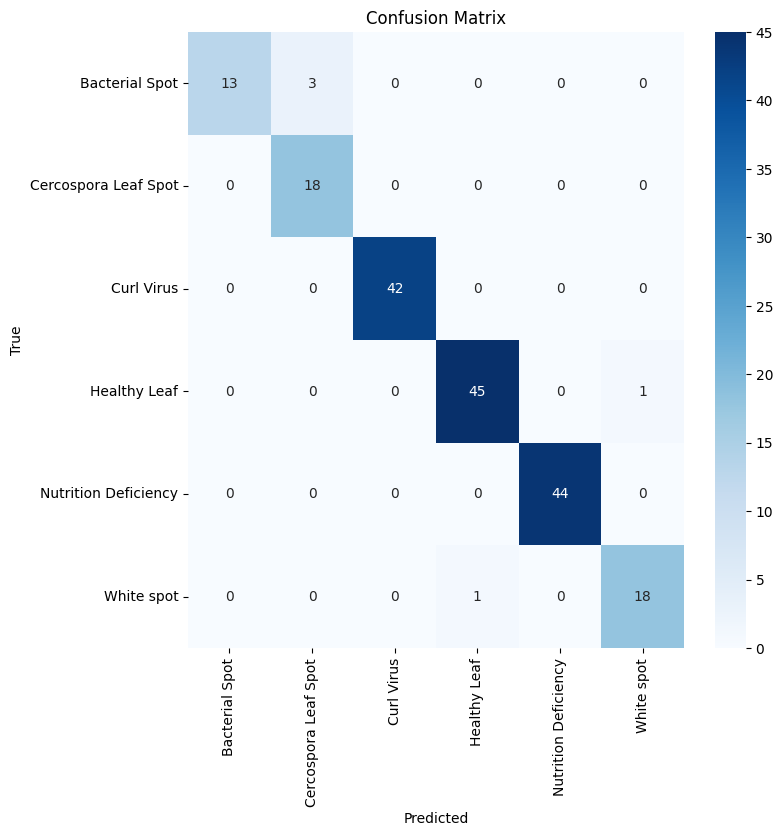

In [ ]:
test_model(trained_model)

**VGG19**

In [ ]:
model_ft = models.vgg19(pretrained=True)
model_ft

In [ ]:
def count_params(model):
  model_params = {"Modules": list(), "Parameters": list()}
  total = {"trainable": 0, "non_trainable": 0}
  for name, parameters in model.named_parameters():
    param = parameters.numel()
    if not parameters.requires_grad:
      total["non_trainable"] += param
      continue
    model_params["Modules"].append(name)
    model_params["Parameters"].append(param)
    total["trainable"] += param
  df = pd.DataFrame(model_params)
  df = df.style.set_caption(f"Total parameters: {total}")
  return df

In [ ]:
count_params(model_ft)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ft.parameters())

In [ ]:
def train_and_validate(model, loss_criterion, optimizer, train_data_loader, valid_data_loader, epochs=25, patience=20):
    model.to(device)
    start = time.time()
    history = []
    best_acc = 0.0
    best_model_wts = model.state_dict()
    no_improvement = 0

    for epoch in range(epochs):
        epoch_start = time.time()
        print("Epoch: {}/{}".format(epoch+1, epochs))

        # Set to training mode
        model.train()

        # Loss and Accuracy within the epoch
        train_loss = 0.0
        train_acc = 0.0

        valid_loss = 0.0
        valid_acc = 0.0

        # Training loop with tqdm for progress tracking
        for i, (inputs, labels) in enumerate(tqdm(train_data_loader, desc="Training")):

            inputs = inputs.to(device)
            labels = labels.to(device)

            # Clean existing gradients
            optimizer.zero_grad()

            # Forward pass - compute outputs on input data using the model
            outputs = model(inputs)

            # Compute loss
            loss = loss_criterion(outputs, labels)

            # Backpropagate the gradients
            loss.backward()

            # Update the parameters
            optimizer.step()

            # Compute the total loss for the batch and add it to train_loss
            train_loss += loss.item() * inputs.size(0)

            # Compute the accuracy
            ret, predictions = torch.max(outputs.data, 1)
            correct_counts = predictions.eq(labels.data.view_as(predictions))

            # Convert correct_counts to float and then compute the mean
            acc = torch.mean(correct_counts.type(torch.FloatTensor))

            # Compute total accuracy in the whole batch and add to train_acc
            train_acc += acc.item() * inputs.size(0)

        # Validation loop with tqdm for progress tracking
        model.eval()  # Set model to evaluation mode
        for j, (inputs, labels) in enumerate(tqdm(valid_data_loader, desc="Validation")):
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass - compute outputs on input data using the model
            outputs = model(inputs)

            # Compute loss
            loss = loss_criterion(outputs, labels)

            # Compute the total loss for the batch and add it to valid_loss
            valid_loss += loss.item() * inputs.size(0)

            # Calculate validation accuracy
            ret, predictions = torch.max(outputs.data, 1)
            correct_counts = predictions.eq(labels.data.view_as(predictions))

            # Convert correct_counts to float and then compute the mean
            acc = torch.mean(correct_counts.type(torch.FloatTensor))

            # Compute total accuracy in the whole batch and add to valid_acc
            valid_acc += acc.item() * inputs.size(0)

        # Find average training loss and training accuracy
        avg_train_loss = train_loss / len(train_data_loader.dataset)
        avg_train_acc = train_acc / len(train_data_loader.dataset)

        # Find average validation loss and validation accuracy
        avg_valid_loss = valid_loss / len(valid_data_loader.dataset)
        avg_valid_acc = valid_acc / len(valid_data_loader.dataset)

        history.append([avg_train_loss, avg_valid_loss, avg_train_acc, avg_valid_acc])

        epoch_end = time.time()

        print("Epoch : {:03d}, Training: Loss: {:.4f}, Accuracy: {:.4f}%, \n\t\tValidation : Loss : {:.4f}, " \
        "Accuracy: {:.4f}%, Time: {:.4f}s".format(epoch + 1, avg_train_loss, avg_train_acc * 100, 
                                                  avg_valid_loss, avg_valid_acc * 100, epoch_end - epoch_start))

        # Save if the model has the best accuracy till now
        if avg_valid_acc > best_acc:
            best_acc = avg_valid_acc
            best_model_wts = model.state_dict()
            no_improvement = 0  # Reset the counter for no improvement
        else:
            no_improvement += 1

        # Check for early stopping
        if no_improvement >= patience:
            print(f'Early stopping after {no_improvement} epochs with no improvement.')
            break

    model.load_state_dict(best_model_wts)

    print("Training complete in {:.0f}m {:.0f}s".format((time.time() - start) // 60, (time.time() - start) % 60))

    return model, history

In [ ]:
trained_model1 = train_and_validate(model_ft, criterion, optimizer, data_loaders['train'], data_loaders['val'], epochs=100)

In [ ]:
print(trained_model1)

In [ ]:
history = np.array(history_values)
plt.plot(history[:,0:2])
plt.legend(['Tr Loss', 'Val Loss'])
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.ylim(0,1)
#plt.savefig(dataset+'_loss_curve.png')
plt.show()

In [ ]:
plt.plot(history[:,2:4])
plt.legend(['Tr Accuracy', 'Val Accuracy'])
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')
plt.ylim(0,1)
#plt.savefig(dataset+'_accuracy_curve.png')
plt.show()

In [ ]:
def test_model(model):
    since = time.time()
    phase = 'test'
    running_corrects = 0
    model.eval()   # Set model to evaluate mode

    preds_all = []
    labels_all = []

    with tqdm(data_loaders[phase], desc=f"{phase} Epoch", unit="batch") as tqdm_epoch:
        for inputs, labels in tqdm_epoch:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            preds_all.extend(preds.cpu().numpy().tolist())
            labels_all.extend(labels.data.cpu().numpy().tolist())

            running_corrects += torch.sum(preds == labels.data)
            tqdm_epoch.set_postfix(accuracy=running_corrects.item() / len(labels_all))

    # Calculate accuracy
    epoch_acc = running_corrects.double() / dataset_sizes[phase]

    # Print classification report
    print(classification_report(labels_all, preds_all))

    # Print accuracy
    print(f'{phase} Acc: {epoch_acc:.4f}')

    # Plot confusion matrix
    plot_confusion_matrix(labels_all, preds_all)

# Function to plot confusion matrix
def plot_confusion_matrix(labels, preds):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

In [ ]:
test_model(trained_model)

**MobileNetV3**

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

In [ ]:
# Load MobileNetV3 (Large version)
model_ft = models.mobilenet_v3_large(pretrained=True)
print(model_ft)

In [ ]:
for param in model_ft.parameters():
    param.requires_grad = False

In [ ]:
model_ft.classifier = nn.Sequential(
    nn.Linear(in_features=960, out_features=128),
    nn.Hardswish(),
    nn.Dropout(p=0.5),
    nn.Linear(in_features=128, out_features=6)
)

print(model_ft)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=1e-4
)

In [ ]:
import time
from tqdm import tqdm

def train_and_validate(model, loss_criterion, optimizer, train_data_loader, valid_data_loader, epochs=25, patience=10):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    history = []
    best_acc = 0.0
    best_model_wts = model.state_dict()
    no_improvement = 0

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # -------- TRAIN --------
        model.train()
        train_loss, train_correct = 0.0, 0

        for inputs, labels in tqdm(train_data_loader, desc="Training"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            loss = loss_criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()

        # -------- VALIDATION --------
        model.eval()
        valid_loss, valid_correct = 0.0, 0

        with torch.no_grad():
            for inputs, labels in tqdm(valid_data_loader, desc="Validation"):
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = loss_criterion(outputs, labels)

                valid_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                valid_correct += (preds == labels).sum().item()

        # -------- METRICS --------
        avg_train_loss = train_loss / len(train_data_loader.dataset)
        avg_valid_loss = valid_loss / len(valid_data_loader.dataset)

        avg_train_acc = train_correct / len(train_data_loader.dataset)
        avg_valid_acc = valid_correct / len(valid_data_loader.dataset)

        history.append([avg_train_loss, avg_valid_loss, avg_train_acc, avg_valid_acc])

        print(f"Train Loss: {avg_train_loss:.4f}, Acc: {avg_train_acc:.4f}")
        print(f"Val   Loss: {avg_valid_loss:.4f}, Acc: {avg_valid_acc:.4f}")

        # -------- EARLY STOPPING --------
        if avg_valid_acc > best_acc:
            best_acc = avg_valid_acc
            best_model_wts = model.state_dict()
            no_improvement = 0
        else:
            no_improvement += 1

        if no_improvement >= patience:
            print("Early stopping triggered")
            break

    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:
trained_model, history = train_and_validate(
    model_ft,
    criterion,
    optimizer,
    data_loaders['train'],
    data_loaders['val'],
    epochs=100
)

In [ ]:
history = np.array(history)

# Loss
plt.plot(history[:,0], label='Train Loss')
plt.plot(history[:,1], label='Val Loss')
plt.legend()
plt.show()

# Accuracy
plt.plot(history[:,2], label='Train Acc')
plt.plot(history[:,3], label='Val Acc')
plt.legend()
plt.show()

In [ ]:
def test_model_mobilenetv3(model):
    since = time.time()
    phase = 'test'
    running_corrects = 0
    model.eval()   # Set model to evaluate mode

    preds_all = []
    labels_all = []

    with tqdm(data_loaders[phase], desc=f"{phase} Epoch", unit="batch") as tqdm_epoch:
        for inputs, labels in tqdm_epoch:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            preds_all.extend(preds.cpu().numpy().tolist())
            labels_all.extend(labels.data.cpu().numpy().tolist())

            running_corrects += torch.sum(preds == labels.data)
            tqdm_epoch.set_postfix(accuracy=running_corrects.item() / len(labels_all))

    # Calculate accuracy
    epoch_acc = running_corrects.double() / dataset_sizes[phase]

    # Print classification report
    print(classification_report(labels_all, preds_all))

    # Print accuracy
    print(f'{phase} Acc: {epoch_acc:.4f}')

    # Plot confusion matrix
    plot_confusion_matrix(labels_all, preds_all)

def plot_confusion_matrix(labels, preds):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

In [ ]:
test_model_mobilenetv3(model_ft)

BarGraph of all models

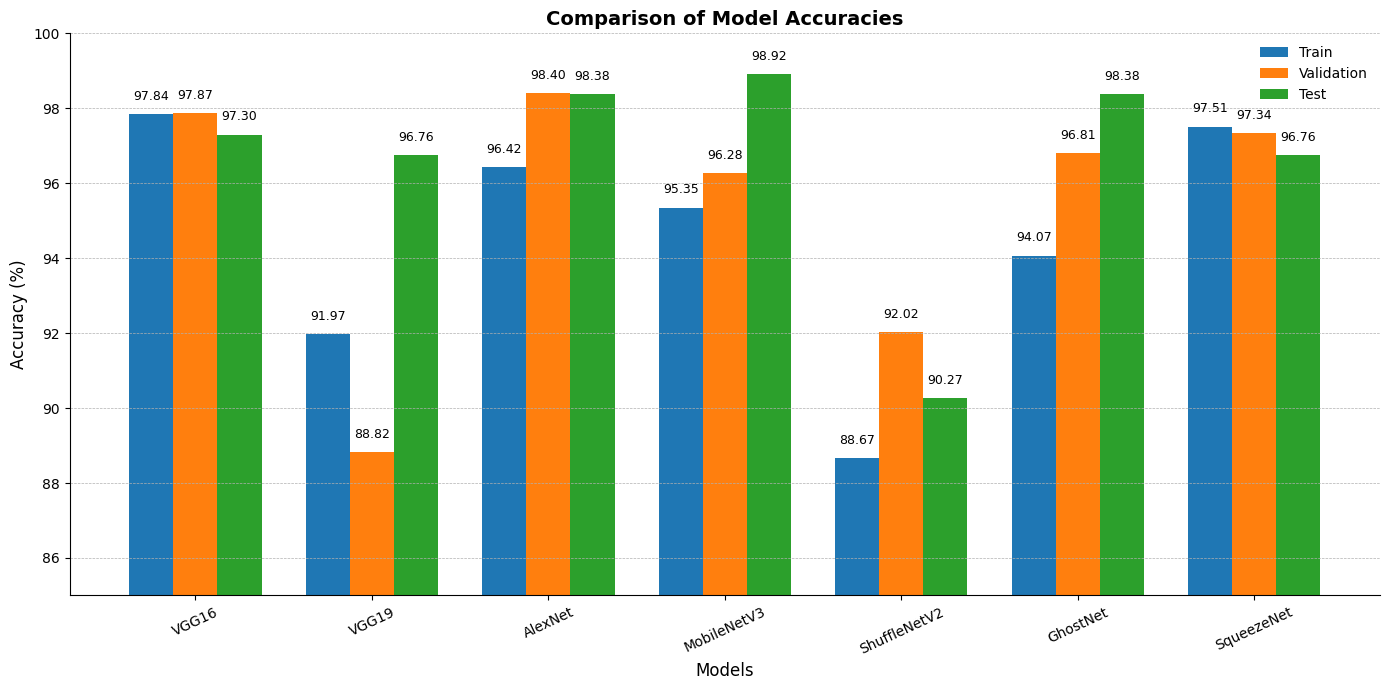

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['VGG16', 'VGG19', 'AlexNet', 'MobileNetV3', 'ShuffleNetV2', 'GhostNet', 'SqueezeNet']
train_acc = [97.84, 91.97, 96.42, 95.35, 88.67, 94.07, 97.51]
val_acc = [97.87, 88.82, 98.40, 96.28, 92.02, 96.81, 97.34]
test_acc = [97.30, 96.76, 98.38, 98.92, 90.27, 98.38, 96.76]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(14, 7))

# Bars
bars1 = plt.bar(x - width, train_acc, width, label='Train')
bars2 = plt.bar(x, val_acc, width, label='Validation')
bars3 = plt.bar(x + width, test_acc, width, label='Test')

# Add value labels on bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height + 0.3,
                 f'{height:.2f}',
                 ha='center', va='bottom', fontsize=9)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

# Labels and title
plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Comparison of Model Accuracies', fontsize=14, fontweight='bold')

# X-axis formatting
plt.xticks(x, models, rotation=25, fontsize=10)

# Y-axis range (tight for better visualization)
plt.ylim(85, 100)

# Grid (light, professional)
plt.grid(axis='y', linestyle='--', linewidth=0.5)

# Legend
plt.legend(frameon=False)

# Remove top/right borders for cleaner look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

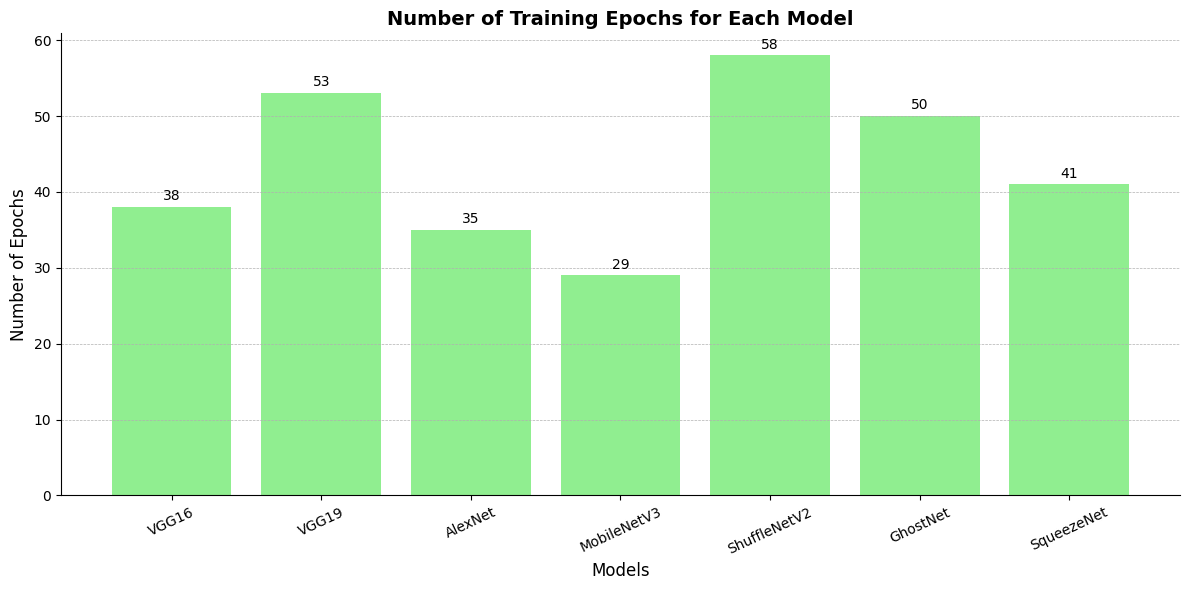

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['VGG16', 'VGG19', 'AlexNet', 'MobileNetV3', 'ShuffleNetV2', 'GhostNet', 'SqueezeNet']
epochs = [38, 53, 35, 29, 58, 50, 41]

x = np.arange(len(models))

plt.figure(figsize=(12, 6))

# Bar plot
bars = plt.bar(x, epochs, color='lightgreen')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.5,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=10)

# Labels and title
plt.xlabel('Models', fontsize=12)
plt.ylabel('Number of Epochs', fontsize=12)
plt.title('Number of Training Epochs for Each Model', fontsize=14, fontweight='bold')

# X-axis formatting
plt.xticks(x, models, rotation=25)

# Grid for clarity
plt.grid(axis='y', linestyle='--', linewidth=0.5)

# Clean look (remove extra borders)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()